# Simulation Analysis

This file is to be used to analyse observable quantities of a simulation

In [121]:

import sys
from pathlib import Path

if sys.platform == "darwin":
    proj = "/Users/rileymcnamara/CODE/2025/silicokit/"
    sys.path.insert(0, proj)
else:
    proj = "C:/Users/riley.mcnamara/Documents/code/silicokit/"
    sys.path.insert(0, proj)

from src.growkit.PlotEngine.SimPlotter import SimPlotter
from src.growkit.PlotEngine.CellFieldPlotter import CellFieldPlotter
from src.growkit.Simulator import TumorGrowthSimulator

simulator = TumorGrowthSimulator(proj + "/configs/T_N.yaml")

simulation_data = simulator.load_simulation_data(proj + "/laboratory/saved_simulations/simulation_data.npz")

sim_plotter = SimPlotter(simulation_data)
cell_plotter = CellFieldPlotter(simulation_data, simulator=simulator)


Pre-compiling Numba functions...
Numba functions compiled successfully!
Loading simulation data from /Users/rileymcnamara/CODE/2025/silicokit//laboratory/saved_simulations/simulation_data.npz...
Loaded simulation data with 21 saved steps


## Radius Evolution

Calculating tumor radius evolution...
Calculating inhibited radius evolution...
Calculating necrotic radius evolution...
Calculating hypoxic radius evolution...


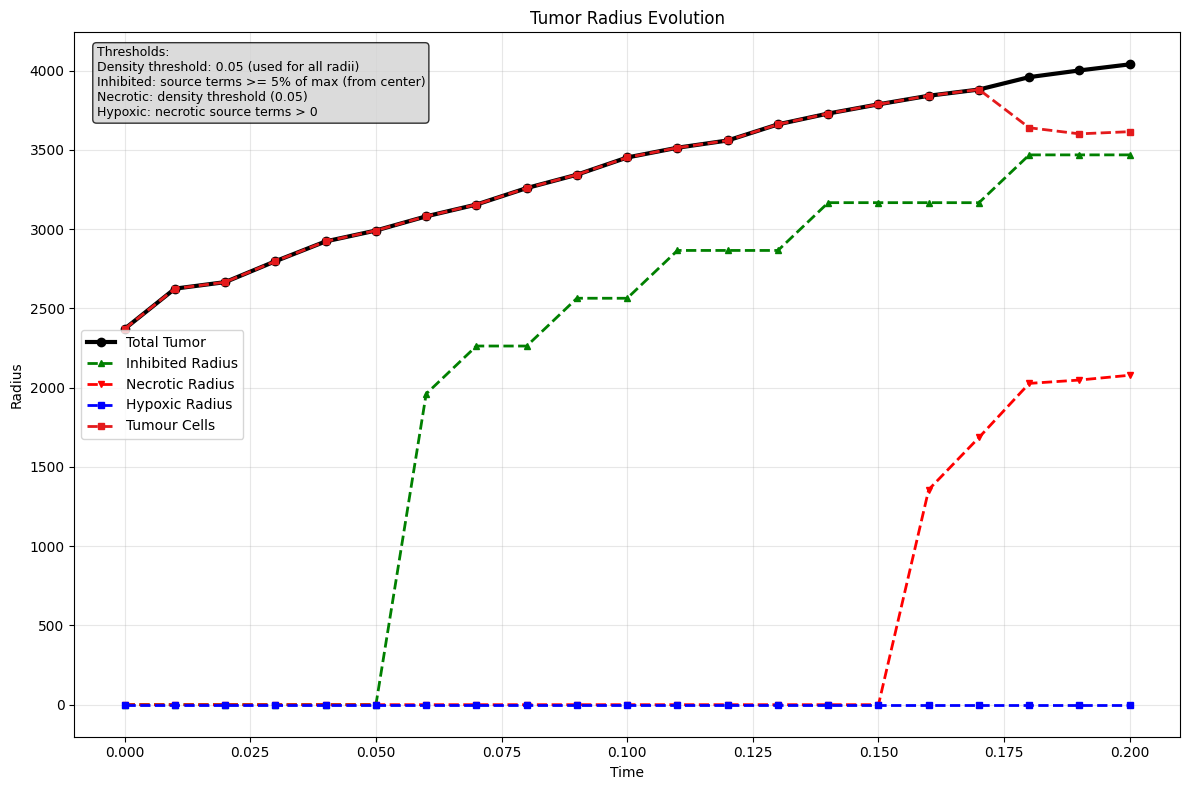

{'total_radii': [np.float64(2370.7213167715126),
  np.float64(2624.193220957674),
  np.float64(2665.4148224517944),
  np.float64(2797.3201163014733),
  np.float64(2922.193830325516),
  np.float64(2990.880414862428),
  np.float64(3080.2775925236856),
  np.float64(3154.749785309597),
  np.float64(3258.5861277655263),
  np.float64(3343.0406053961165),
  np.float64(3451.557886511697),
  np.float64(3513.2287599550677),
  np.float64(3558.9205027902776),
  np.float64(3660.454023457729),
  np.float64(3728.827853129376),
  np.float64(3786.8230445830523),
  np.float64(3841.0508070379756),
  np.float64(3880.1987951536603),
  np.float64(3958.46181471953),
  np.float64(4000.676891631124),
  np.float64(4039.007242641518)],
 'population_radii': {'Tumour Cells': [np.float64(2370.7213167715126),
   np.float64(2624.1932086849224),
   np.float64(2665.41480659162),
   np.float64(2797.3199505191674),
   np.float64(2922.193796116461),
   np.float64(2990.8783607114765),
   np.float64(3080.275897213896),
   n

In [122]:
sim_plotter.plot_tumor_radius_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), include_individual_populations=True, threshold=0.05, method='contour', growth_threshold=0.45)

In [123]:
#sim_plotter.plot_density_and_source_with_radii()

## Population Density Evolution

Plotting evolution for population: Tumour Cells (index: 0)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


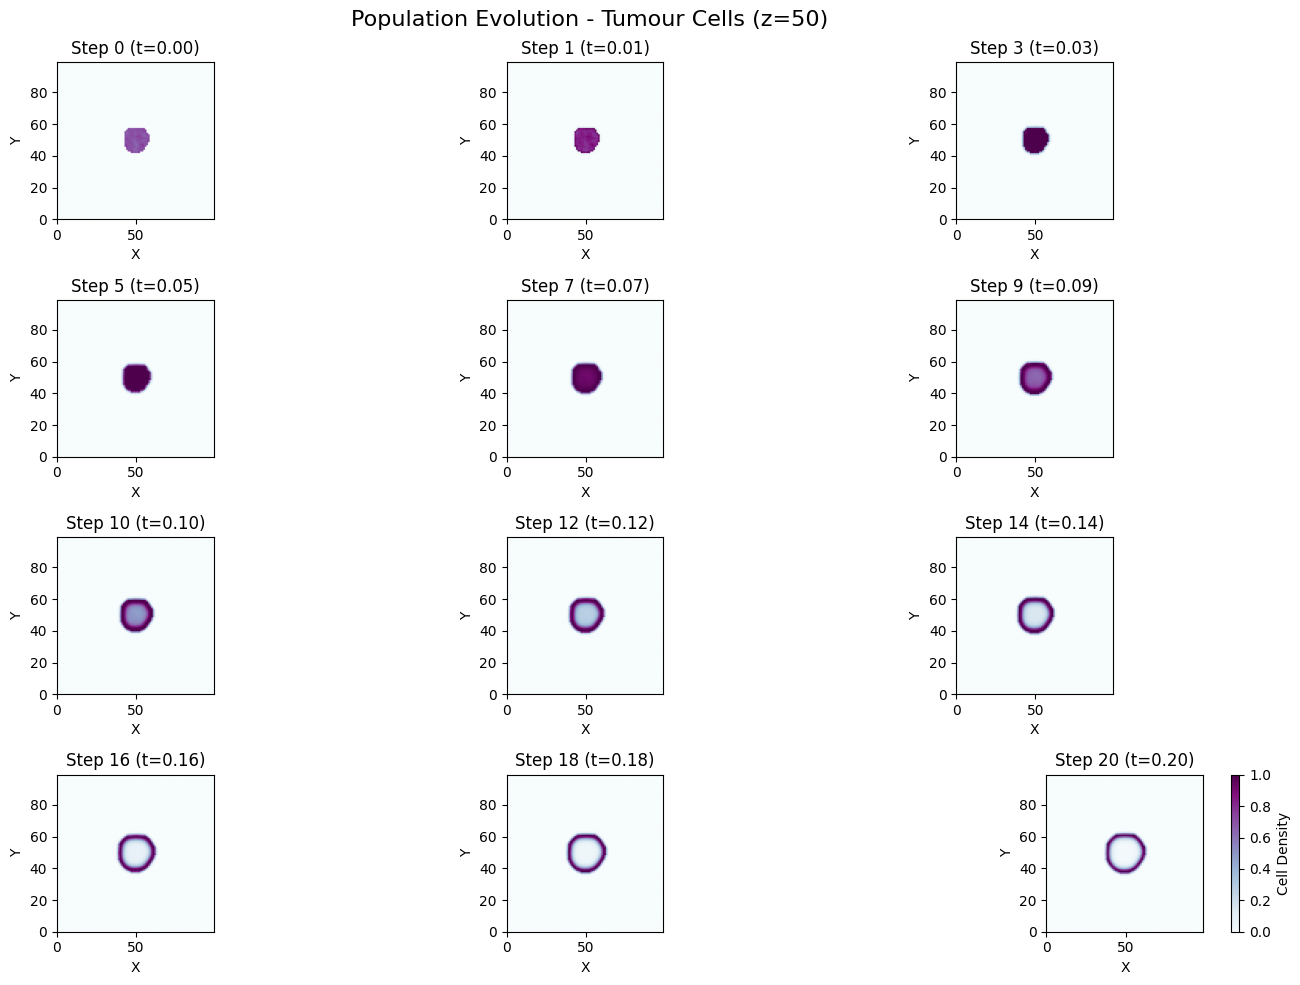

In [124]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Tumour Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Necrotic Cells (index: 1)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


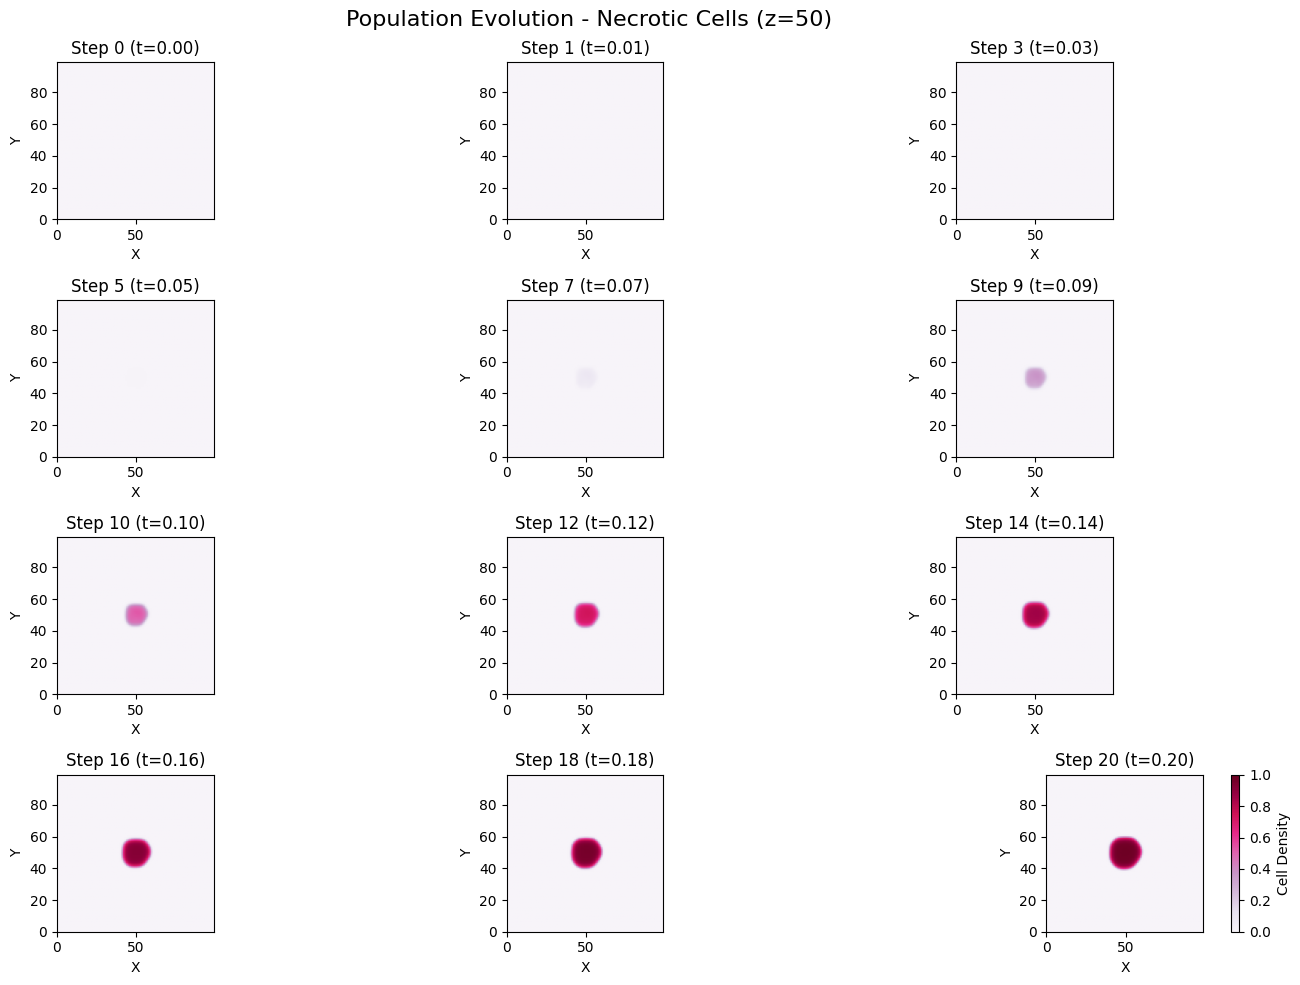

In [125]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Necrotic Cells", cmap="PuRd", show_plot=True)

Creating nutrient field evolution plot...


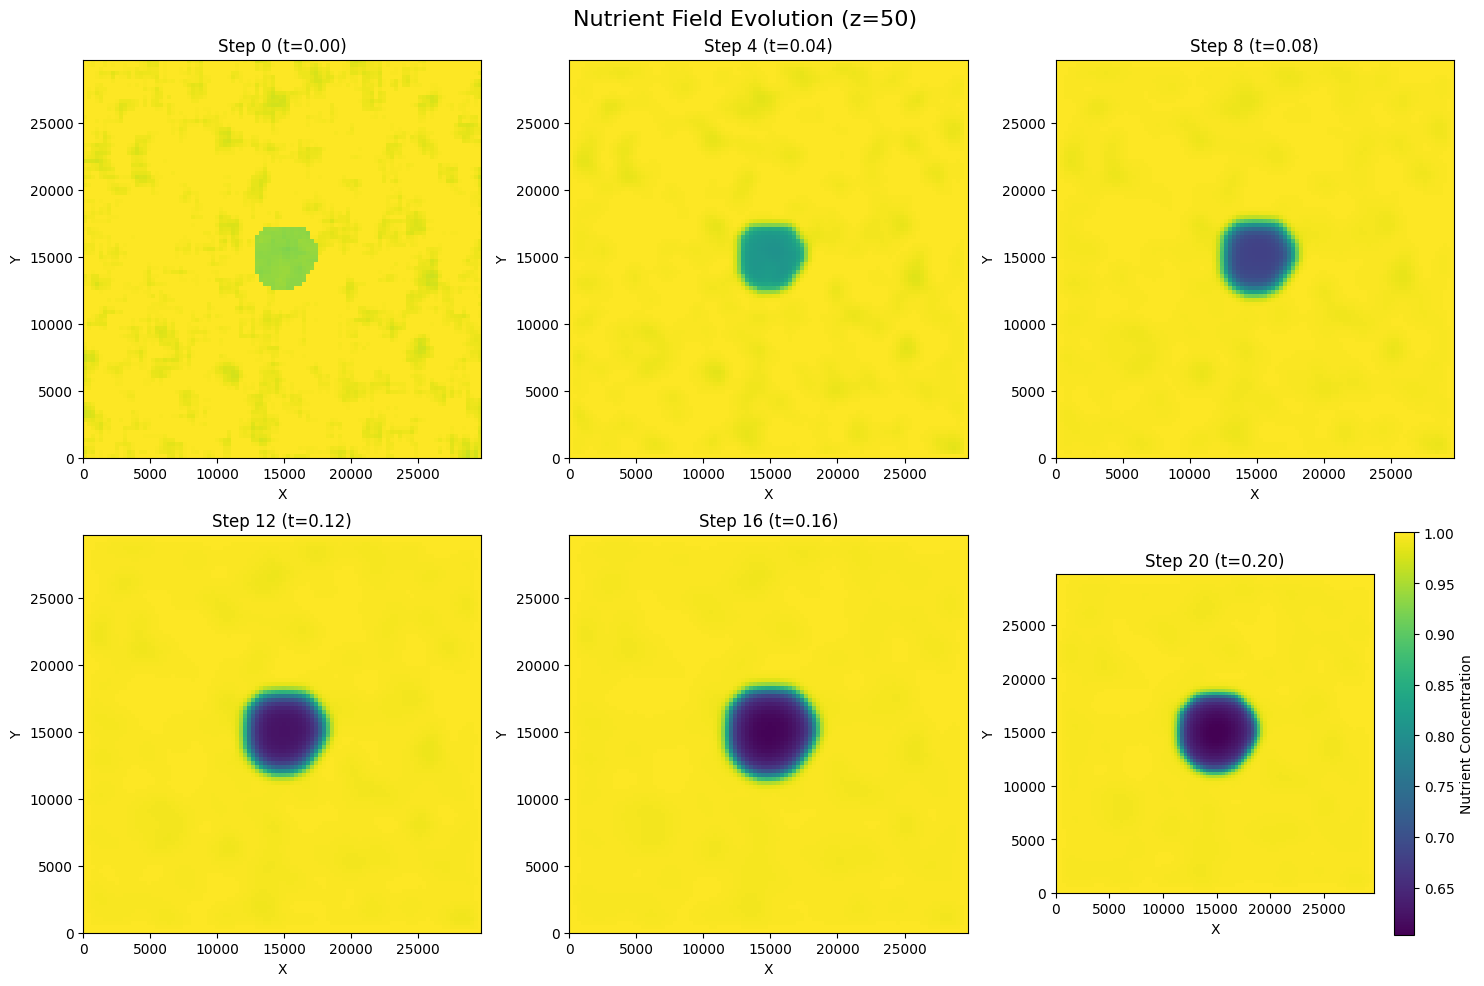

In [126]:
sim_plotter.plot_nutrient_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="viridis", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating source field evolution plot...


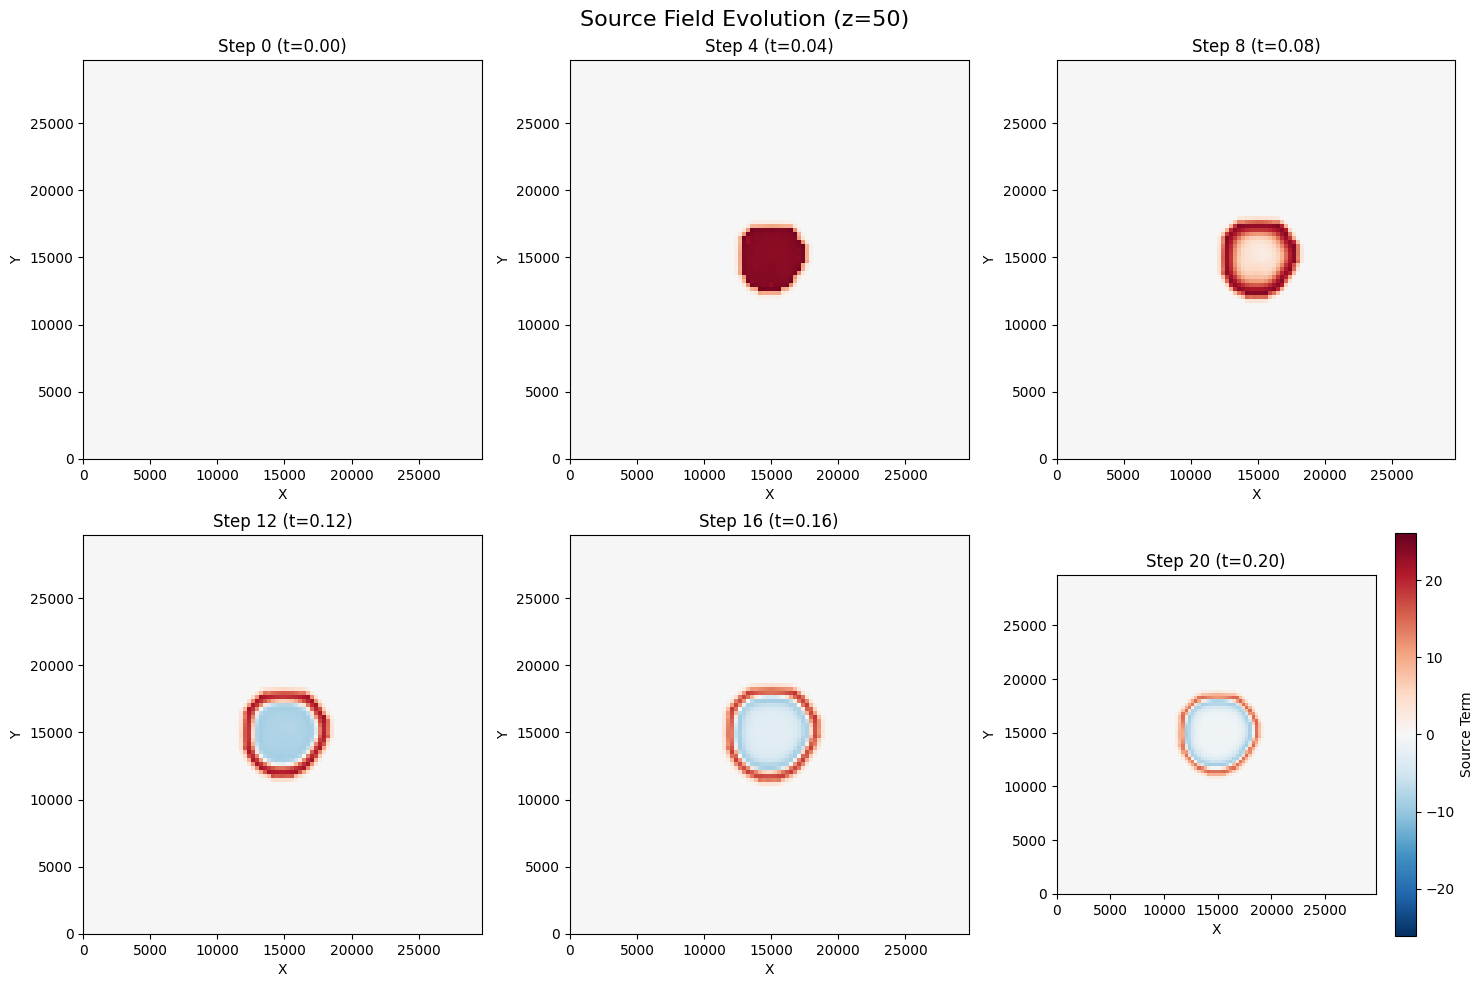

In [127]:
sim_plotter.plot_source_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="RdBu_r", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating radius diagnostic plot...
Radius diagnostic plot saved to path/to/output/radius_diagnostic_z50_threshold0.1.png


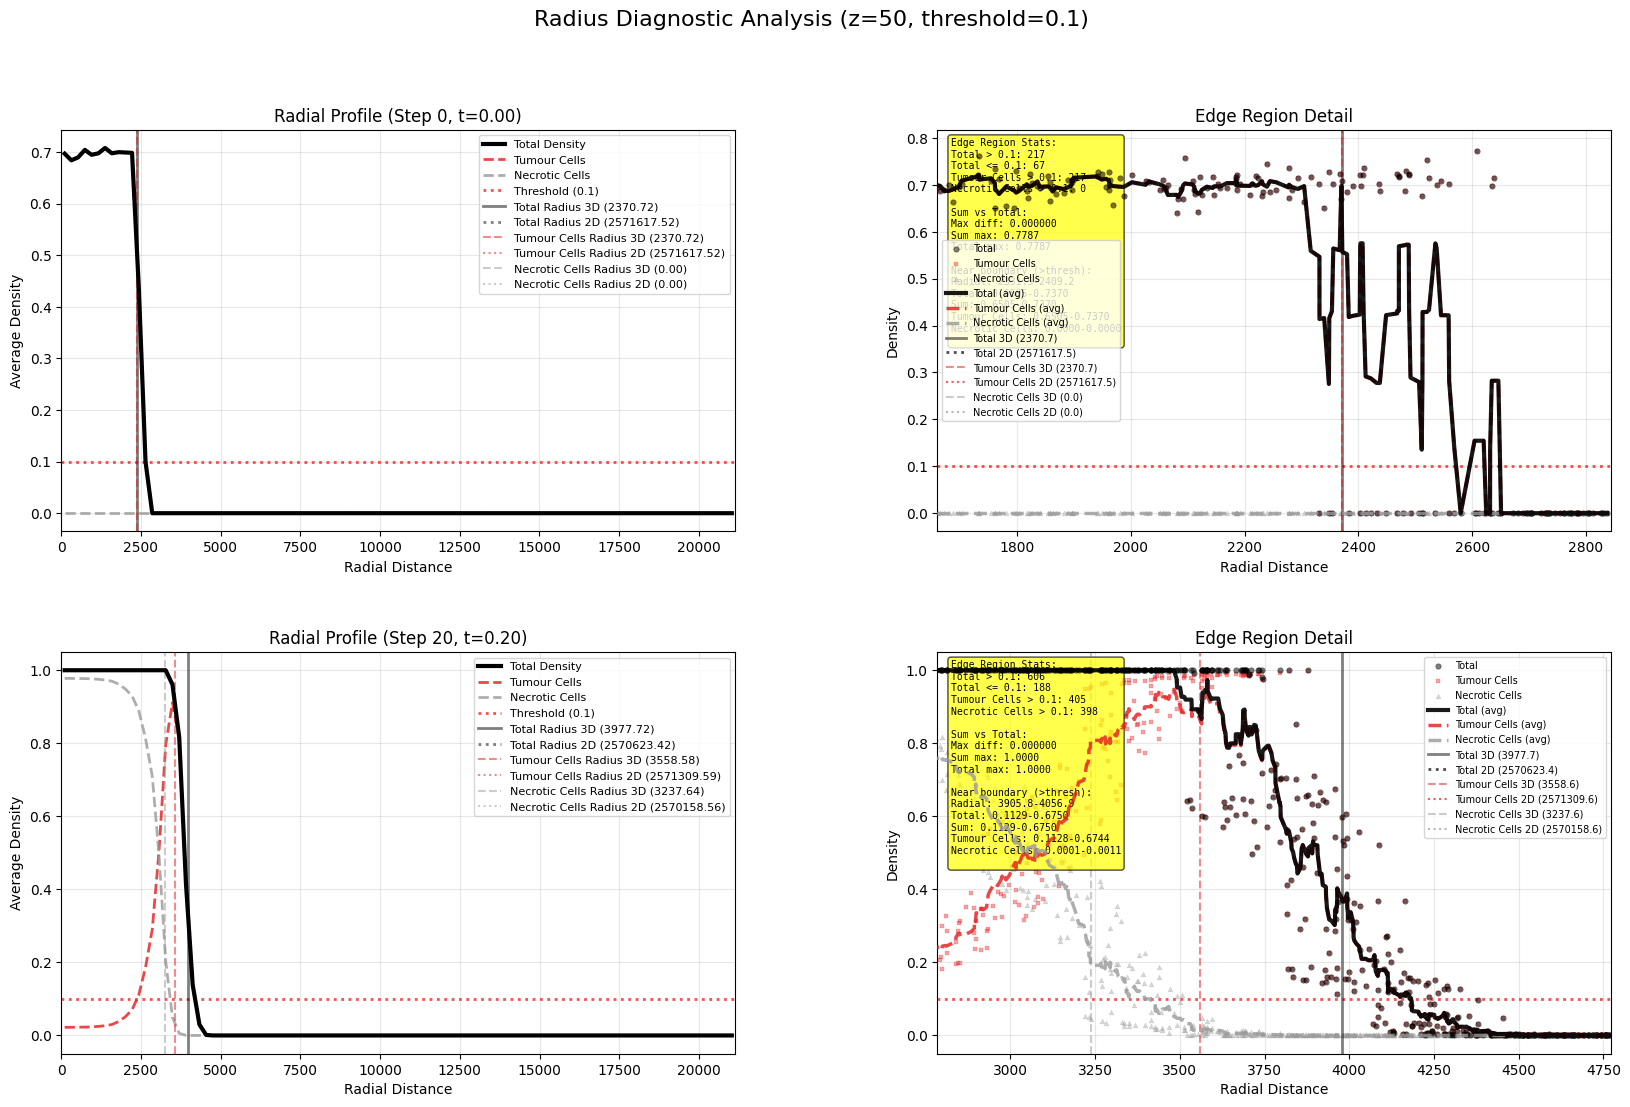

{'step_indices': [0, 20],
 'individual_radii': {0: {'Tumour Cells': np.float64(2370.7213167715126),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(3558.579178196321),
   'Necrotic Cells': np.float64(3237.6425521313354)}},
 'total_radii': {0: np.float64(2370.7213167715126),
  20: np.float64(3977.7191318234272)},
 'z_slice': 50,
 'threshold': 0.1,
 'total_radii_2d': {0: np.float64(2571617.5229413873),
  20: np.float64(2570623.423861481)},
 'individual_radii_2d': {0: {'Tumour Cells': np.float64(2571617.5229413873),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(2571309.5888320925),
   'Necrotic Cells': np.float64(2570158.5621021567)}}}

In [128]:
# In your notebook or script:
sim_plotter.plot_radius_diagnostic(
    output_dir='path/to/output',
    save_plot=True,
    step_indices=[0, 50, -1],  # Compare early, middle, and late time steps
    threshold=0.1,  # Use the same threshold as your radius plot
    method='contour'
)